# Parameter Estimation Example

This notebook shows how to reproduce the parameter estimation from our pipeline. Given the trigger from the catalog it performs the parameter estimation.

In [1]:
import subprocess
from datetime import datetime, timedelta

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from corner import corner
from tqdm import tqdm
from astropy.io import fits as pyfits

from gdt.missions.fermi.time import Time

from grpype.data_io.data_handlers import TTEData
from grpype.pipeline_executers import resolve_config
from grpype.followup.parameter_estimation import FullResponseHandler, BandFunction
from grpype.followup.parameter_estimation import extract_stats

# Load configuration (prints data path for sanity).
config = resolve_config()
DATAPATH = config.data_path
print(f"Using data path: {config.data_path}")

%matplotlib inline

Using data path: /Users/arielpe/PythonProjects/grb_detection_docker/grb_detection/data


In [2]:
burst_dict = {
    0.002: (10, 30),
    0.003: (10, 30),
    0.004: (10, 30),
    0.005: (10, 30),
    0.007: (10, 30),
    0.009: (10, 30),
    0.012: (10, 30),
    0.016: (10, 30),
    0.022: (10, 30),
    0.03: (40, 120),
    0.04: (40, 120),
    0.054: (40, 120),
    0.073: (40, 120),
    0.098: (40, 120),
    0.133: (60, 180),
    0.179: (60, 180),
    0.242: (60, 180),
    0.327: (60, 180),
    0.441: (60, 180),
    0.596: (60, 180),
    0.804: (60, 180),
    1.086: (60, 180),
    1.466: (100, 270),
    1.979: (100, 270),
    2.671: (100, 270),
    3.606: (100, 300),
    4.869: (100, 300),
    6.573: (100, 300),
}

slcs = [
    [0.0, 0.053],
    [0.048, 0.105],
    [0.09999999999999999, 0.158],
    [0.153, 0.211],
    [0.206, 0.263],
    [0.258, 0.316],
    [0.311, 0.368],
    [0.363, 0.421],
    [0.416, 0.474],
    [0.469, 0.526],
    [0.521, 0.579],
    [0.574, 0.632],
    [0.627, 0.684],
    [0.679, 0.737],
    [0.732, 0.789],
    [0.784, 0.842],
    [0.837, 0.895],
    [0.89, 0.947],
    [0.942, 1.0]
]

def get_closest_burst(t, burst_dict):
    closest_key = min(burst_dict.keys(), key=lambda k: abs(k - t))
    return burst_dict[closest_key]


In [3]:
trigdf = pd.read_csv(DATAPATH / 'catalogs/perera_et_al_2026_gbm_grb_catalog.csv')
trigdf['trigtime'] = pd.to_datetime(trigdf['trigtime'])

In [4]:
ddate = datetime(2017, 8, 17, 12, 41)

row = trigdf[(trigdf.trigtime.dt.year == ddate.year) & (trigdf.trigtime.dt.month == ddate.month) & (trigdf.trigtime.dt.day == ddate.day) & (trigdf.trigtime.dt.hour == ddate.hour) & (trigdf.trigtime.dt.minute == ddate.minute)]
j = row.index[0]

In [5]:
binning = trigdf.loc[j, 'search_binning']
burst_duration = trigdf.loc[j, 'duration']
date = trigdf.loc[j, 'trigtime'].to_pydatetime()
trigmet = Time(date, scale='utc')
slc_ind = trigdf.loc[j, 'slc_index']
snr = trigdf.loc[j, 'snr']

if binning < 0.01:
    cut_len_seconds = 0
    slc = slcs[int(slc_ind)]
else:
    cut_len_seconds = 10
    slc = None

init_guess = [trigdf.loc[j, 'ra_max'], trigdf.loc[j, 'dec_max'], trigdf.loc[j, 'band_alpha_max'], trigdf.loc[j, 'band_beta_max'], trigdf.loc[j, 'band_epeak_max']]

In [6]:
burstdata = TTEData(date, binning, burst_duration, cut_len_seconds=cut_len_seconds, slice_time=slc)

trigger_time_samp = np.searchsorted(burstdata.time, trigmet.fermi)
if trigger_time_samp < burstdata.full_gti_inds[0][0]:
    date = date - timedelta(hours=1)
    shiftflag = True
elif trigger_time_samp > burstdata.full_gti_inds[-1][-1]:
    date = date + timedelta(hours=1)
    shiftflag = True
else:
    shiftflag = False

if shiftflag:
    del burstdata
    burstdata = TTEData(date, binning, burst_duration, cut_len_seconds=cut_len_seconds, slice_time=slc)


In [ ]:
# burstdata.set_burst_duration()
spec_model = BandFunction()
offset = 0

# For this you will need a set of responses in the folder 'PE_231027145949' (or change the name to match your folder of responses).
handler = FullResponseHandler(burstdata, trigmet, burst_duration, binning, spec_model, trig_offset=offset, rsp_folder='PE_231027145949')  # PE_221220110138

# If you don't have responses, this will generate the responses for different angular resolutions.
# Note that you will need the gbm response generator installed (in perl, see readme for more information).
# Also note that it takes a long time to generate the responses, especially for finer angular resolutions.
# ang_res = 4.0
# handler = FullResponseHandler.from_gbm_resps_bank(ang_res, burstdata, trigmet, burst_duration, binning, spec_model, verbose=True, radec_bounds=bounds)

2017-08-17 12:40:08.000256 2017-08-17 12:43:07.830739


In [8]:
sampler = handler.run_mcmc(initial_guess=init_guess, nwalkers=32, nsteps=1000)
samples = sampler.get_chain(discard=100, flat=True)

param_stats = extract_stats(samples)

display(param_stats[['ra_med', 'dec_med', 'alpha_med', 'beta_med', 'epeak_med']])
display(param_stats[['ra_max', 'dec_max', 'alpha_max', 'beta_max', 'epeak_max']])

100%|██████████| 1000/1000 [00:11<00:00, 86.46it/s]


,ra_med,dec_med,alpha_med,beta_med,epeak_med
0,188.279442,-19.225528,-0.549679,-4.646083,186.152454


,ra_max,dec_max,alpha_max,beta_max,epeak_max
0,188.274077,-18.660285,-0.683405,-5.190451,162.87148


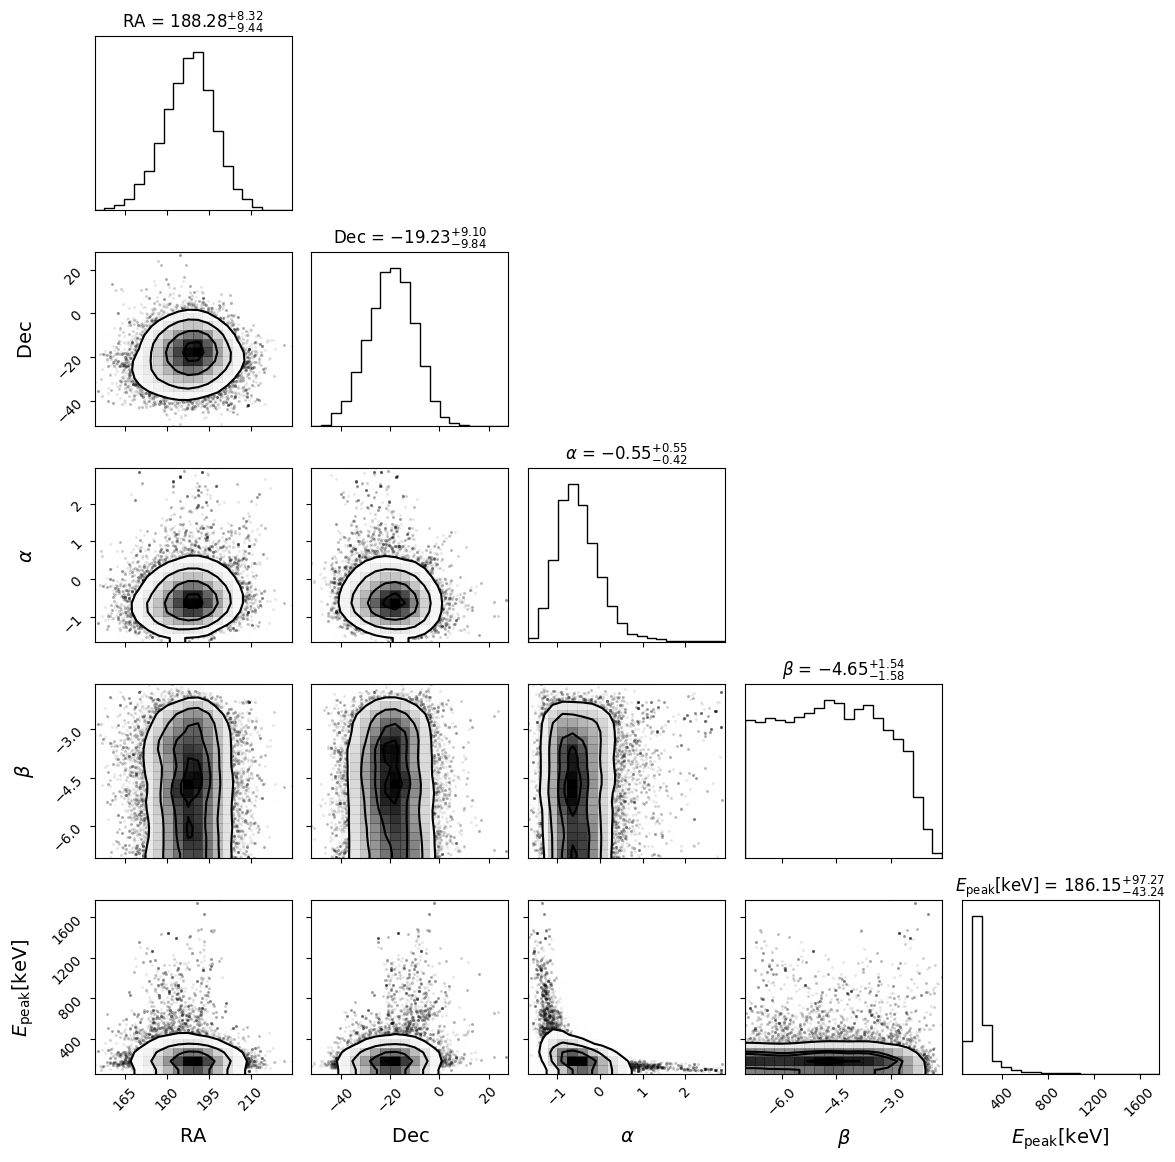

In [9]:
# ll = sampler.get_log_prob(discard=100, flat=True)
labels = [r"$\mathrm{RA}$", r"$\mathrm{Dec}$",
          r"$\alpha$", r"$\beta$", 
          r"$E_{\mathrm{peak}} [\mathrm{keV}]$", r"log-likelihood"]


fig = corner(samples, labels=labels, show_titles=True,
                    title_fmt=".2f", title_kwargs={"fontsize": 12}, 
                    label_kwargs={"fontsize": 14}, 
                    # quantiles=[0.05, 0.5, 0.95],
                    plot_density=True, plot_datapoints=True,
                    smooth=1.0)
plt.tight_layout()
plt.show()


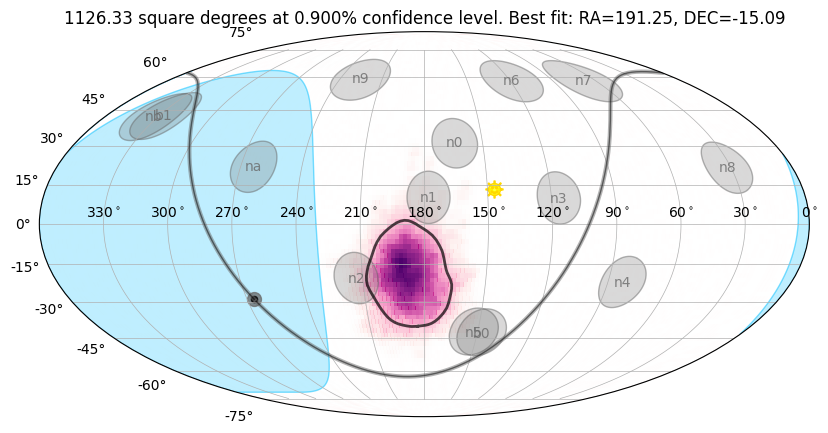

In [10]:
fermiplot, hpmap = handler.plot_skymap(samples, clevels=[0.9], fwhm_deg=3.0)

In [11]:
handler.calc_localization_stats(*samples[:, :2].T)

(2.5351139030883423e-05, 0.0)

2000it [00:01, 1491.73it/s]


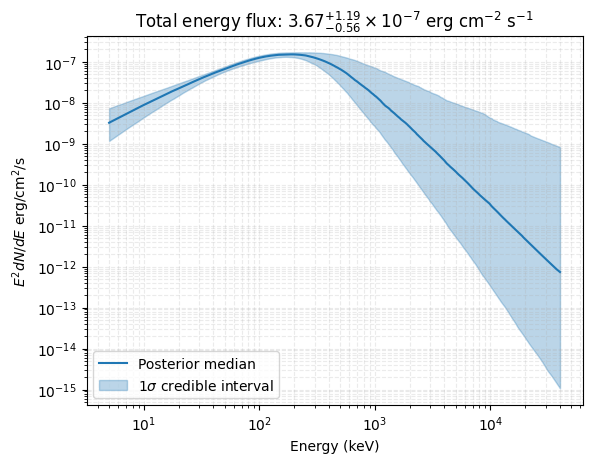

In [12]:
nsamples = 2_000
indices = np.arange(len(samples))
indices = np.random.choice(indices, nsamples, replace=True)
kev2erg = 1.60218e-9

nebins = int(1e4)
ebins = 10**np.linspace(np.log10(5), np.log10(40_000), nebins)

diff_energy_flux = np.zeros([nsamples, nebins])
tot_energy_flux = np.zeros(nsamples)

for i, ind in tqdm(enumerate(indices)):
    ra = samples[ind, 0]
    dec = samples[ind, 1]
    alpha = samples[ind, 2]
    beta = samples[ind, 3]
    epeak = samples[ind, 4]
    
    diff_photon_flux = handler.calc_diff_photon_flux(ra, dec, [alpha, beta, epeak], ebins=ebins)
    diff_energy_flux[i, :] = kev2erg*ebins**2*diff_photon_flux

    tot_energy_flux[i] = np.sum((ebins * diff_photon_flux)[:-1] * np.diff(ebins)) * kev2erg


mean_diff_energy_flux = np.median(diff_energy_flux, axis=0)
errp_diff_energy_flux = np.percentile(diff_energy_flux, 84, axis=0)
errm_diff_energy_flux = np.percentile(diff_energy_flux, 16, axis=0)

mean_tot_energy_flux = np.median(tot_energy_flux)
errp_tot_energy_flux = np.percentile(tot_energy_flux, 84) - mean_tot_energy_flux
errm_tot_energy_flux = mean_tot_energy_flux - np.percentile(tot_energy_flux, 16)

plt.plot(ebins, mean_diff_energy_flux, 'C0', label='Posterior median')
plt.fill_between(ebins, errm_diff_energy_flux, errp_diff_energy_flux, color='C0', alpha=0.3, label='1$\sigma$ credible interval')

exp = int(np.floor(np.log10(abs(mean_tot_energy_flux))))
base = mean_tot_energy_flux / (10**exp)
err_plus_base = errp_tot_energy_flux / (10**exp)
err_minus_base = errm_tot_energy_flux / (10**exp)

# Build LaTeX title string
title = ('Total energy flux: '
    fr"${base:.2f}^{{+{err_plus_base:.2f}}}_{{-{err_minus_base:.2f}}}"
    fr"\times 10^{{{exp}}}\ \mathrm{{erg\ cm^{{-2}}\ s^{{-1}}}}$"
)
plt.title(title, fontsize=12)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy (keV)')
plt.ylabel(f'$E^2 dN/dE$ erg/cm$^2$/s')
plt.grid(which='both', ls='--', alpha=0.25)
plt.legend()
plt.show()
